✅ Libraries imported successfully
✅ Data loaded successfully!
   Total customers: 5,878
   Scaled features shape: (5878, 13)
   PCA features shape: (5878, 8)

📋 Features for clustering:
    1. Recency
    2. Frequency
    3. Monetary
    4. R_Score
    5. F_Score
    6. M_Score
    7. RFM_Score
    8. AvgOrderValue
    9. ValuePerDay
   10. AvgTransactionValue
   11. CustomerLifetime
   12. PurchaseFrequency
   13. UniqueProducts

📊 K-Means Evaluation:
------------------------------------------------------------
   K= 2 | Silhouette: 0.3566 | DB: 1.1513 | CH: 1994
   K= 3 | Silhouette: 0.3621 | DB: 1.2130 | CH: 1700
   K= 4 | Silhouette: 0.3626 | DB: 0.8565 | CH: 1886
   K= 5 | Silhouette: 0.3452 | DB: 0.8958 | CH: 2041
   K= 6 | Silhouette: 0.3468 | DB: 0.7281 | CH: 2029
   K= 7 | Silhouette: 0.3070 | DB: 0.8328 | CH: 2039
   K= 8 | Silhouette: 0.3052 | DB: 0.8700 | CH: 1998
   K= 9 | Silhouette: 0.2923 | DB: 0.9081 | CH: 1969
   K=10 | Silhouette: 0.2803 | DB: 0.9340 | CH: 1972


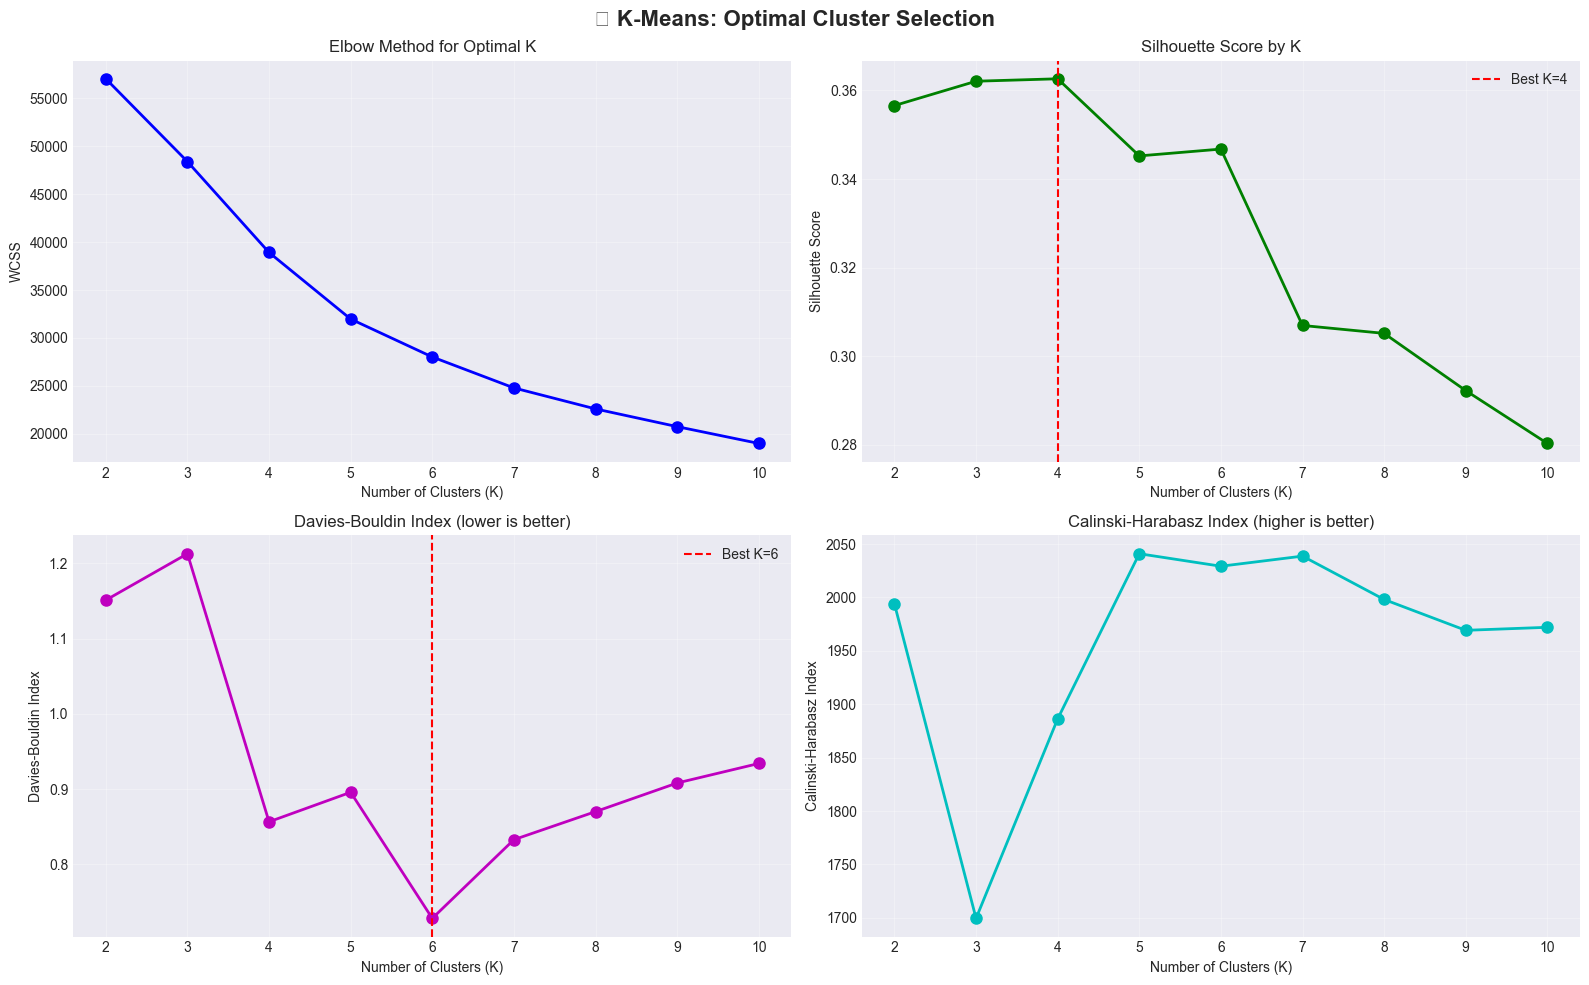


🎯 Optimal K for K-Means: 4
✅ K-Means clustering completed with 4 clusters


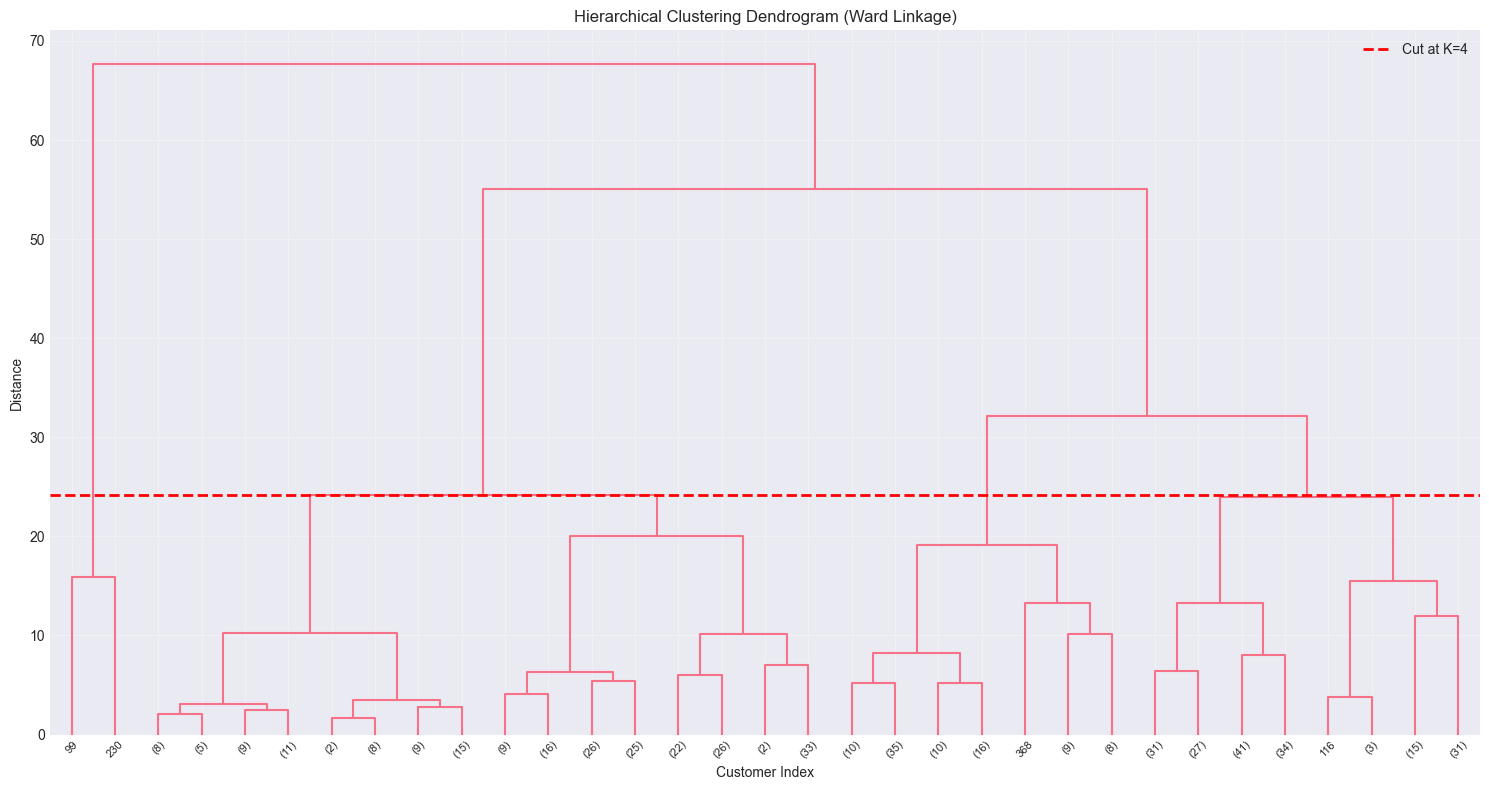


📊 Hierarchical Clustering Evaluation:
--------------------------------------------------
   K= 2 | Silhouette: 0.3023
   K= 3 | Silhouette: 0.3048
   K= 4 | Silhouette: 0.2853
   K= 5 | Silhouette: 0.2834
   K= 6 | Silhouette: 0.2837
   K= 7 | Silhouette: 0.2743
   K= 8 | Silhouette: 0.2546
   K= 9 | Silhouette: 0.2498
   K=10 | Silhouette: 0.2416

🎯 Optimal K for Hierarchical Clustering: 3
✅ Hierarchical clustering completed with 3 clusters


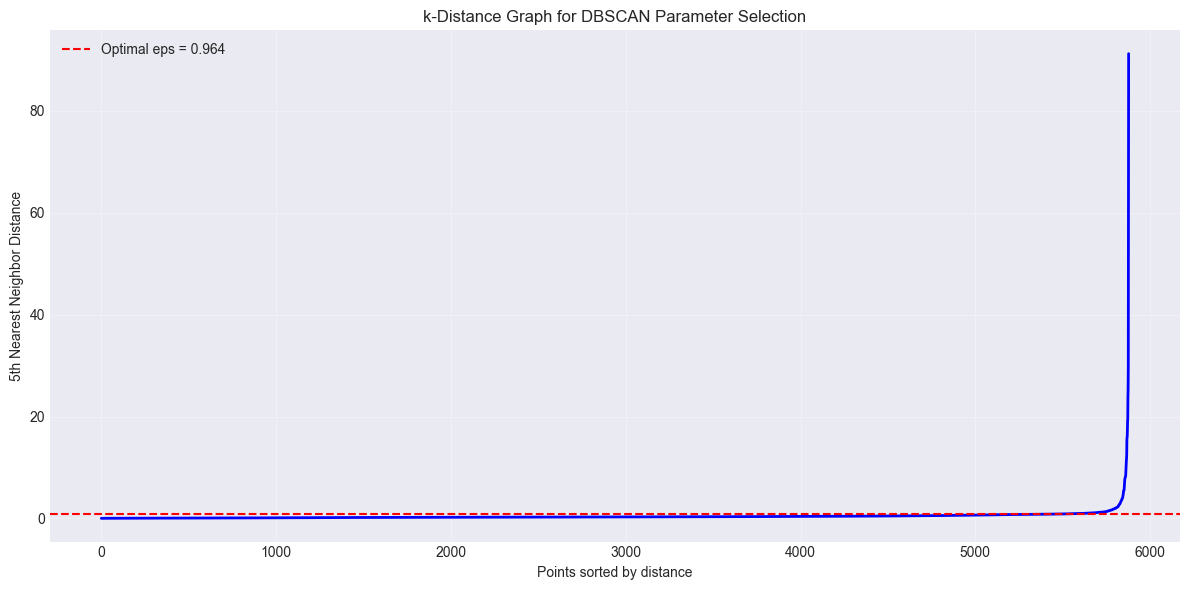


🎯 Optimal eps: 0.9643

📊 DBSCAN Parameter Tuning:
----------------------------------------------------------------------
   eps=0.300, min_samples=3 → clusters=227, noise=27.3%, silhouette=0.2755
   eps=0.300, min_samples=4 → clusters=163, noise=33.2%, silhouette=0.2996
   eps=0.300, min_samples=5 → clusters=130, noise=38.0%, silhouette=0.3268
   eps=0.300, min_samples=6 → clusters=117, noise=42.7%, silhouette=0.3468
   eps=0.300, min_samples=7 → clusters=107, noise=47.0%, silhouette=0.3663
   eps=0.300, min_samples=8 → clusters=84, noise=52.1%, silhouette=0.3808
   eps=0.300, min_samples=9 → clusters=79, noise=55.4%, silhouette=0.4042
   eps=0.300, min_samples=10 → clusters=62, noise=60.2%, silhouette=0.4178
   eps=0.400, min_samples=3 → clusters=154, noise=17.8%, silhouette=0.1954
   eps=0.400, min_samples=4 → clusters=127, noise=21.0%, silhouette=0.2193
   eps=0.400, min_samples=5 → clusters=107, noise=23.9%, silhouette=0.2317
   eps=0.400, min_samples=6 → clusters=99, noise=26.4%,

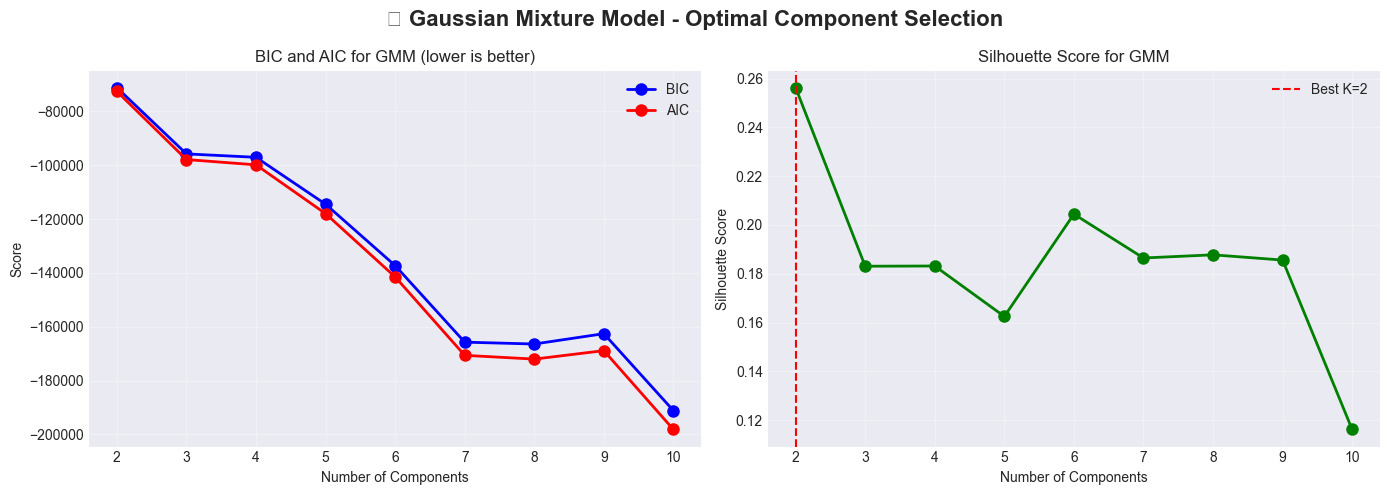


🎯 Optimal components for GMM: 2
✅ GMM clustering completed with 2 components


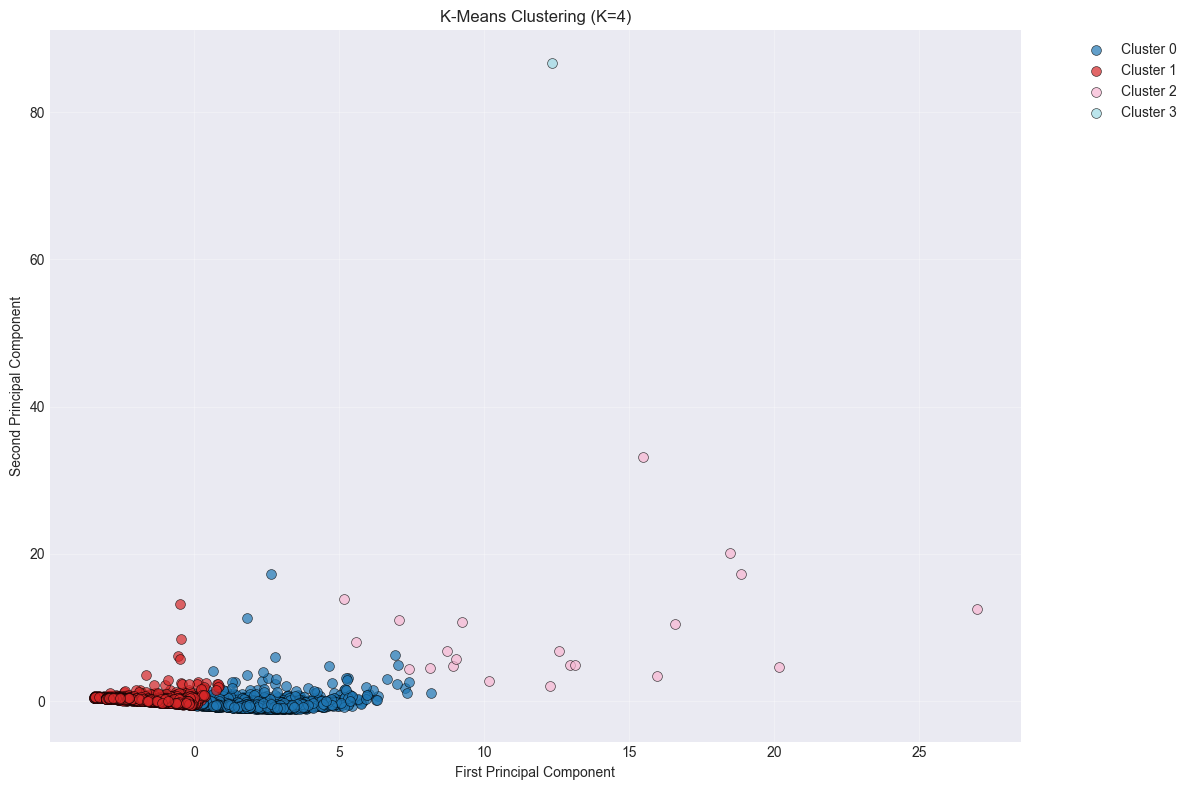

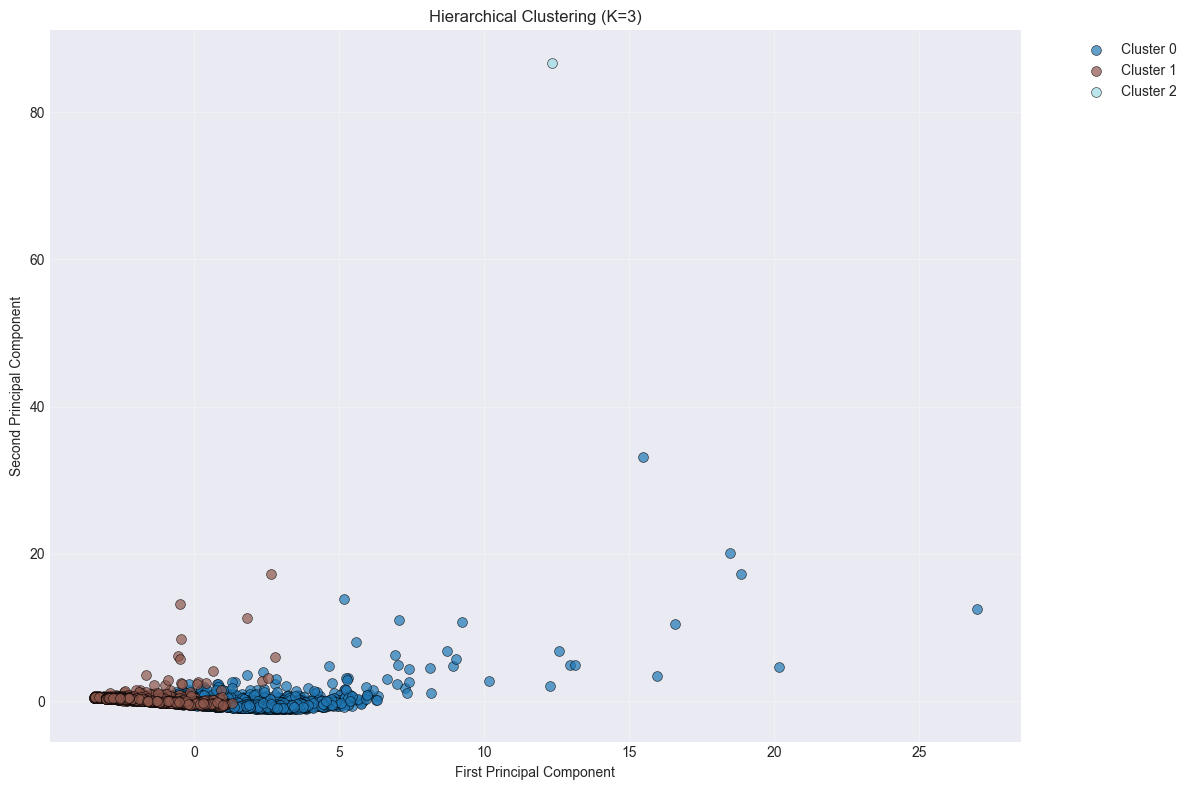

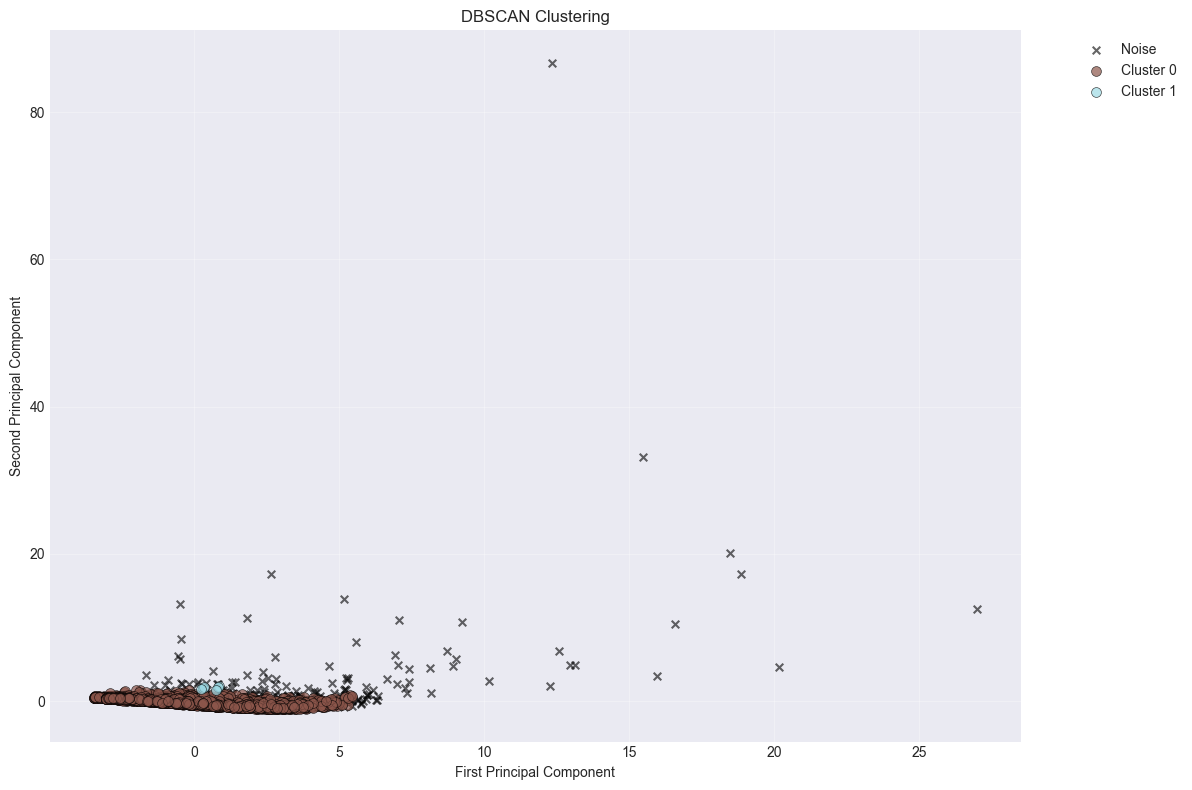

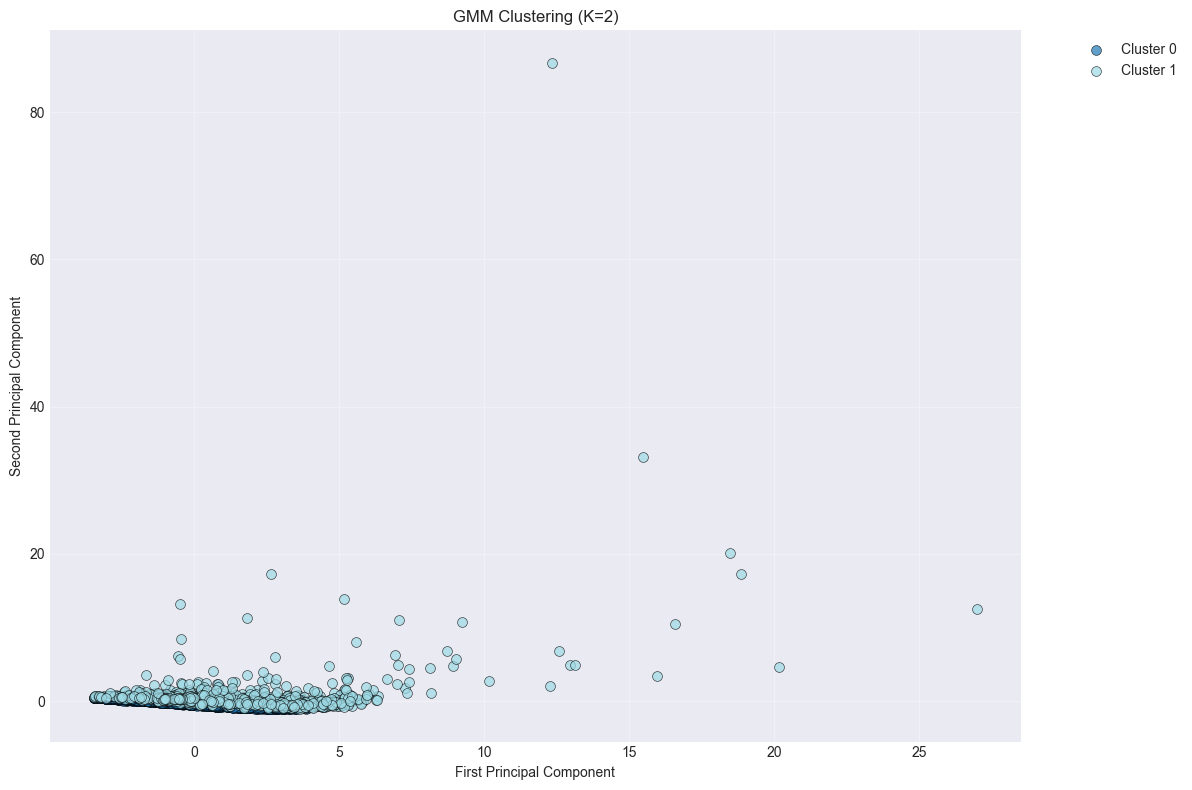

✅ Cluster assignments saved to: ../results/cluster_assignments.csv

📊 Clustering Summary:
   K-Means: 4 clusters
   Hierarchical: 3 clusters
   DBSCAN: 2 clusters
   GMM: 2 clusters


In [2]:
# %% [markdown]
# # 🧠 04 - Clustering Models
# ## Customer Segmentation Project

# %% [markdown]
# ### Import Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✅ Libraries imported successfully")

# %% [markdown]
# ### Load Preprocessed Data

# %%
# Load features
try:
    customer_features = pd.read_csv('../data/processed/customer_features.csv')
    scaled_features = pd.read_csv('../data/processed/scaled_features.csv')
    pca_features = pd.read_csv('../data/processed/pca_features.csv')
    
    # Extract feature matrices
    X_scaled = scaled_features.drop('CustomerID', axis=1).values
    X_pca = pca_features.drop('CustomerID', axis=1).values
    
    print(f"✅ Data loaded successfully!")
    print(f"   Total customers: {len(customer_features):,}")
    print(f"   Scaled features shape: {X_scaled.shape}")
    print(f"   PCA features shape: {X_pca.shape}")
    
    # Display feature names
    feature_names = scaled_features.drop('CustomerID', axis=1).columns.tolist()
    print(f"\n📋 Features for clustering:")
    for i, name in enumerate(feature_names, 1):
        print(f"   {i:2d}. {name}")
except FileNotFoundError as e:
    print(f"❌ Error loading data: {e}")
    print("Please run 03_feature_engineering.ipynb first")

# %% [markdown]
# ## 1️⃣ K-Means Clustering

# %%
def evaluate_kmeans(X, max_k=10):
    """Evaluate K-Means for different values of K"""
    wcss = []
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_scores = []
    
    print("\n📊 K-Means Evaluation:")
    print("-" * 60)
    
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        wcss.append(kmeans.inertia_)
        
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(X, labels)
            db = davies_bouldin_score(X, labels)
            ch = calinski_harabasz_score(X, labels)
        else:
            sil = -1
            db = float('inf')
            ch = 0
        
        silhouette_scores.append(sil)
        davies_bouldin_scores.append(db)
        calinski_scores.append(ch)
        
        print(f"   K={k:2d} | Silhouette: {sil:.4f} | DB: {db:.4f} | CH: {ch:.0f}")
    
    return {
        'wcss': wcss,
        'silhouette': silhouette_scores,
        'davies_bouldin': davies_bouldin_scores,
        'calinski': calinski_scores
    }

# Evaluate K-Means
if 'X_scaled' in dir():
    kmeans_metrics = evaluate_kmeans(X_scaled, max_k=10)

# %%
if 'kmeans_metrics' in dir():
    # Visualize K-Means metrics
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    k_range = range(2, 11)
    
    # Elbow Method
    axes[0, 0].plot(k_range, kmeans_metrics['wcss'], 'bo-', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Number of Clusters (K)')
    axes[0, 0].set_ylabel('WCSS')
    axes[0, 0].set_title('Elbow Method for Optimal K')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Silhouette Score
    axes[0, 1].plot(k_range, kmeans_metrics['silhouette'], 'go-', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Number of Clusters (K)')
    axes[0, 1].set_ylabel('Silhouette Score')
    axes[0, 1].set_title('Silhouette Score by K')
    axes[0, 1].grid(True, alpha=0.3)
    
    best_k_sil = k_range[np.argmax(kmeans_metrics['silhouette'])]
    axes[0, 1].axvline(x=best_k_sil, color='red', linestyle='--', 
                        label=f'Best K={best_k_sil}')
    axes[0, 1].legend()
    
    # Davies-Bouldin Index
    axes[1, 0].plot(k_range, kmeans_metrics['davies_bouldin'], 'mo-', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Number of Clusters (K)')
    axes[1, 0].set_ylabel('Davies-Bouldin Index')
    axes[1, 0].set_title('Davies-Bouldin Index (lower is better)')
    axes[1, 0].grid(True, alpha=0.3)
    
    best_k_db = k_range[np.argmin(kmeans_metrics['davies_bouldin'])]
    axes[1, 0].axvline(x=best_k_db, color='red', linestyle='--',
                        label=f'Best K={best_k_db}')
    axes[1, 0].legend()
    
    # Calinski-Harabasz Index
    axes[1, 1].plot(k_range, kmeans_metrics['calinski'], 'co-', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Number of Clusters (K)')
    axes[1, 1].set_ylabel('Calinski-Harabasz Index')
    axes[1, 1].set_title('Calinski-Harabasz Index (higher is better)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('📊 K-Means: Optimal Cluster Selection', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/kmeans_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()

# %%
if 'kmeans_metrics' in dir():
    # Select optimal K and train final model
    optimal_k = best_k_sil
    print(f"\n🎯 Optimal K for K-Means: {optimal_k}")
    
    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
    kmeans_labels = final_kmeans.fit_predict(X_scaled)
    
    print(f"✅ K-Means clustering completed with {optimal_k} clusters")
else:
    optimal_k = 5
    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
    kmeans_labels = final_kmeans.fit_predict(X_scaled)

# %% [markdown]
# ## 2️⃣ Hierarchical Clustering

# %%
if 'X_scaled' in dir():
    # Create dendrogram (using sample for better visualization)
    sample_size = min(500, len(X_scaled))
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[sample_idx]
    
    # Calculate linkage matrix
    linkage_matrix = linkage(X_sample, method='ward')
    
    # Plot dendrogram
    plt.figure(figsize=(15, 8))
    dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=0)
    if optimal_k <= len(linkage_matrix):
        plt.axhline(y=linkage_matrix[-optimal_k, 2], color='red', linestyle='--', 
                    linewidth=2, label=f'Cut at K={optimal_k}')
    plt.xlabel('Customer Index')
    plt.ylabel('Distance')
    plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/dendrogram.png', dpi=150, bbox_inches='tight')
    plt.show()

# %%
def evaluate_hierarchical(X, max_clusters=10):
    """Evaluate Hierarchical clustering"""
    silhouette_scores = []
    
    print("\n📊 Hierarchical Clustering Evaluation:")
    print("-" * 50)
    
    for k in range(2, max_clusters + 1):
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = hierarchical.fit_predict(X)
        
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(X, labels)
        else:
            sil = -1
        
        silhouette_scores.append(sil)
        print(f"   K={k:2d} | Silhouette: {sil:.4f}")
    
    return silhouette_scores

if 'X_scaled' in dir():
    # Evaluate Hierarchical
    hierarchical_scores = evaluate_hierarchical(X_scaled, max_clusters=10)
    
    # Find optimal K
    optimal_k_hier = np.argmax(hierarchical_scores) + 2
    print(f"\n🎯 Optimal K for Hierarchical Clustering: {optimal_k_hier}")
    
    # Train final model
    final_hierarchical = AgglomerativeClustering(n_clusters=optimal_k_hier, linkage='ward')
    hierarchical_labels = final_hierarchical.fit_predict(X_scaled)
    
    print(f"✅ Hierarchical clustering completed with {optimal_k_hier} clusters")
else:
    optimal_k_hier = optimal_k
    final_hierarchical = AgglomerativeClustering(n_clusters=optimal_k_hier, linkage='ward')
    hierarchical_labels = final_hierarchical.fit_predict(X_scaled)

# %% [markdown]
# ## 3️⃣ DBSCAN Clustering

# %%
def find_optimal_eps(X, k=5):
    """Find optimal epsilon using k-distance graph"""
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, _ = neighbors_fit.kneighbors(X)
    
    k_distances = np.sort(distances[:, k-1])
    return k_distances

if 'X_scaled' in dir():
    # Find optimal eps
    k_distances = find_optimal_eps(X_scaled, k=5)
    
    # Plot k-distance graph
    plt.figure(figsize=(12, 6))
    plt.plot(k_distances, 'b-', linewidth=2)
    
    # Find elbow point (95th percentile)
    elbow_idx = int(len(k_distances) * 0.95)
    optimal_eps = k_distances[elbow_idx]
    
    plt.axhline(y=optimal_eps, color='red', linestyle='--', 
                label=f'Optimal eps = {optimal_eps:.3f}')
    plt.xlabel('Points sorted by distance')
    plt.ylabel('5th Nearest Neighbor Distance')
    plt.title('k-Distance Graph for DBSCAN Parameter Selection')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/dbscan_kdistance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n🎯 Optimal eps: {optimal_eps:.4f}")

# %%
def tune_dbscan(X, eps_values, min_samples_range):
    """Tune DBSCAN parameters"""
    results = []
    
    print("\n📊 DBSCAN Parameter Tuning:")
    print("-" * 70)
    
    for eps in eps_values:
        for min_samples in min_samples_range:
            # Ensure min_samples is integer
            min_samples_int = int(min_samples)
            dbscan = DBSCAN(eps=eps, min_samples=min_samples_int)
            labels = dbscan.fit_predict(X)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_pct = (n_noise / len(labels)) * 100 if len(labels) > 0 else 0
            
            if n_clusters > 1:
                mask = labels != -1
                if mask.sum() > 1:
                    try:
                        sil = silhouette_score(X[mask], labels[mask])
                    except:
                        sil = -1
                else:
                    sil = -1
            else:
                sil = -1
            
            results.append({
                'eps': eps,
                'min_samples': min_samples_int,
                'n_clusters': n_clusters,
                'noise_pct': noise_pct,
                'silhouette': sil
            })
            
            print(f"   eps={eps:.3f}, min_samples={min_samples_int} → clusters={n_clusters}, "
                  f"noise={noise_pct:.1f}%, silhouette={sil:.4f}")
    
    return pd.DataFrame(results)

if 'X_scaled' in dir():
    # Test different parameters
    eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    min_samples_range = [3, 4, 5, 6, 7, 8, 9, 10]
    
    dbscan_results = tune_dbscan(X_scaled, eps_values, min_samples_range)
    
    # Find best parameters
    valid_results = dbscan_results[dbscan_results['n_clusters'] > 1]
    if len(valid_results) > 0:
        best_dbscan = valid_results.loc[valid_results['silhouette'].idxmax()]
        print(f"\n🎯 Best DBSCAN Parameters:")
        print(f"   eps: {best_dbscan['eps']:.3f}")
        print(f"   min_samples: {int(best_dbscan['min_samples'])}")
        print(f"   clusters: {int(best_dbscan['n_clusters'])}")
        print(f"   noise: {best_dbscan['noise_pct']:.1f}%")
        print(f"   silhouette: {best_dbscan['silhouette']:.4f}")
        
        # Train final DBSCAN - ensure min_samples is integer
        final_dbscan = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
        dbscan_labels = final_dbscan.fit_predict(X_scaled)
        
        n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        
        print(f"\n✅ DBSCAN clustering completed:")
        print(f"   Clusters: {n_clusters_dbscan}")
        print(f"   Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
    else:
        print("\n⚠️ No valid DBSCAN clustering found, using K-Means labels")
        dbscan_labels = kmeans_labels
        n_clusters_dbscan = optimal_k
else:
    dbscan_labels = kmeans_labels
    n_clusters_dbscan = optimal_k

# %% [markdown]
# ## 4️⃣ Gaussian Mixture Model (GMM)

# %%
def evaluate_gmm(X, max_components=10):
    """Evaluate GMM using BIC, AIC, and Silhouette"""
    bic_scores = []
    aic_scores = []
    silhouette_scores = []
    
    print("\n📊 GMM Evaluation:")
    print("-" * 60)
    
    for k in range(2, max_components + 1):
        gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full')
        gmm.fit(X)
        labels = gmm.predict(X)
        
        bic_scores.append(gmm.bic(X))
        aic_scores.append(gmm.aic(X))
        
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(X, labels)
        else:
            sil = -1
        
        silhouette_scores.append(sil)
        print(f"   K={k:2d} | BIC: {gmm.bic(X):.0f} | AIC: {gmm.aic(X):.0f} | Silhouette: {sil:.4f}")
    
    return {
        'bic': bic_scores,
        'aic': aic_scores,
        'silhouette': silhouette_scores
    }

if 'X_scaled' in dir():
    # Evaluate GMM
    gmm_metrics = evaluate_gmm(X_scaled, max_components=10)
    
    # Visualize GMM metrics
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    k_range = range(2, 11)
    
    # BIC and AIC
    axes[0].plot(k_range, gmm_metrics['bic'], 'bo-', linewidth=2, markersize=8, label='BIC')
    axes[0].plot(k_range, gmm_metrics['aic'], 'ro-', linewidth=2, markersize=8, label='AIC')
    axes[0].set_xlabel('Number of Components')
    axes[0].set_ylabel('Score')
    axes[0].set_title('BIC and AIC for GMM (lower is better)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Silhouette scores
    axes[1].plot(k_range, gmm_metrics['silhouette'], 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Score for GMM')
    axes[1].grid(True, alpha=0.3)
    
    best_k_gmm = k_range[np.argmax(gmm_metrics['silhouette'])]
    axes[1].axvline(x=best_k_gmm, color='red', linestyle='--',
                    label=f'Best K={best_k_gmm}')
    axes[1].legend()
    
    plt.suptitle('📊 Gaussian Mixture Model - Optimal Component Selection', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/gmm_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Train final GMM
    optimal_gmm = best_k_gmm
    print(f"\n🎯 Optimal components for GMM: {optimal_gmm}")
    
    final_gmm = GaussianMixture(n_components=optimal_gmm, random_state=42, covariance_type='full')
    gmm_labels = final_gmm.fit_predict(X_scaled)
    
    print(f"✅ GMM clustering completed with {optimal_gmm} components")
else:
    optimal_gmm = optimal_k
    final_gmm = GaussianMixture(n_components=optimal_gmm, random_state=42, covariance_type='full')
    gmm_labels = final_gmm.fit_predict(X_scaled)

# %% [markdown]
# ## 5️⃣ Visualize Clustering Results

# %%
def plot_clusters_2d(X, labels, title, save_path=None):
    """Plot clusters in 2D using first two PCA components"""
    plt.figure(figsize=(12, 8))
    
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        if label == -1:
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', 
                       s=30, alpha=0.6, label='Noise')
        else:
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], c=[colors[i]], 
                       s=50, alpha=0.7, edgecolor='black', linewidth=0.5,
                       label=f'Cluster {label}')
    
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

if 'X_pca' in dir() and 'kmeans_labels' in dir():
    # Plot results
    plot_clusters_2d(X_pca, kmeans_labels, 
                     f'K-Means Clustering (K={optimal_k})',
                     '../results/cluster_plots/kmeans_clusters.png')
    
    plot_clusters_2d(X_pca, hierarchical_labels,
                     f'Hierarchical Clustering (K={optimal_k_hier})',
                     '../results/cluster_plots/hierarchical_clusters.png')
    
    plot_clusters_2d(X_pca, dbscan_labels,
                     f'DBSCAN Clustering',
                     '../results/cluster_plots/dbscan_clusters.png')
    
    plot_clusters_2d(X_pca, gmm_labels,
                     f'GMM Clustering (K={optimal_gmm})',
                     '../results/cluster_plots/gmm_clusters.png')

# %%
# Save cluster assignments
if 'customer_features' in dir() and 'CustomerID' in customer_features.columns:
    results_df = customer_features[['CustomerID']].copy()
else:
    results_df = pd.DataFrame({'CustomerID': range(len(kmeans_labels))})

results_df['KMeans_Cluster'] = kmeans_labels
results_df['Hierarchical_Cluster'] = hierarchical_labels
results_df['DBSCAN_Cluster'] = dbscan_labels
results_df['GMM_Cluster'] = gmm_labels

# Create results directory if it doesn't exist
import os
os.makedirs('../results', exist_ok=True)

results_df.to_csv('../results/cluster_assignments.csv', index=False)
print(f"✅ Cluster assignments saved to: ../results/cluster_assignments.csv")

# Display summary
print("\n📊 Clustering Summary:")
print(f"   K-Means: {len(np.unique(kmeans_labels))} clusters")
print(f"   Hierarchical: {len(np.unique(hierarchical_labels))} clusters")
print(f"   DBSCAN: {len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)} clusters")
print(f"   GMM: {len(np.unique(gmm_labels))} clusters")

# %% [markdown]
# ### ✅ Summary
# 
# - **K-Means**: {len(np.unique(kmeans_labels))} clusters
# - **Hierarchical**: {len(np.unique(hierarchical_labels))} clusters
# - **DBSCAN**: {len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)} clusters
# - **GMM**: {len(np.unique(gmm_labels))} components
# 
# **Next Step**: Proceed to Model Comparison (05_model_comparison.ipynb)